In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

'''#Run this to regenerate the .npy files for the data
df = pd.read_parquet("data/RMDC26_Beginner_Tier_test.parquet")
print(df.columns)
print(df.shape)

event_names = [f"RMDC26_{i:06d}" for i in range(1, 189)]

# event names are from RMDC26_000001 to RMDC26_000188
# filters are ['F087', 'F146', 'F213']

def makeFliterDataMatrix(filter, df):
  res = []
  filter_name = filter
  for event_id in event_names:
    res.append(df.loc[(df["name"] == event_id) & (df["filt"] == filter_name), ["mag","mag_err","bjd"]].sort_values("bjd").to_numpy().T)
  return np.array(res)

F087 = makeFliterDataMatrix("F087", df)
print(F087.shape)
F146 = makeFliterDataMatrix("F146", df)
print(F146.shape)
F213 = makeFliterDataMatrix("F213", df)
print(F146.shape)

np.save("data/F087.npy", F087)
np.save("data/F146.npy", F146)
np.save("data/F213.npy", F213)'''

F087 = np.load("data/F087.npy")
F146 = np.load("data/F146.npy")
F213 = np.load("data/F213.npy")

In [47]:
# Now we have three numpy matrices for each filter.
# They have dims 188 x 3 x c
# 188 events, 3 features saved for each event (mag, mag err, bjd time), and then c raw channels

# Noise baseline: for each event, the mean (and S.D.) of the light curve's own
# magnitude values. Most of a light curve is flat noise around this baseline;
# the lensing event shows up as a sustained deviation away from it.

F087_mags = F087[:, 0, :]   # (n_events, n_points)
bjd = F087[0, 2, :]         # shared time axis

baseline_mean = F087_mags.mean(axis=1)   # (n_events,)
baseline_std = F087_mags.std(axis=1)     # (n_events,)

In [48]:
def find_anomalies(series, mean, std, threshold=3.0, tol=5):
    """
    Find sustained-deviation anomalies in a 1D light curve.

    threshold : n, number of S.D. from the baseline mean that counts as
                "above threshold".
    tol       : d, a run must exceed this many consecutive points to
                start (or end) an anomaly.

    An anomaly starts at the first point of a run of more than `tol`
    consecutive points that are more than `threshold` S.D. from the
    mean, and ends at the first point of the following run of more
    than `tol` consecutive points that fall back under the threshold.

    Returns a list of (start_idx, end_idx) index pairs, inclusive.
    """
    dev = np.abs(series - mean) > threshold * std

    anomalies = []
    above_run = 0
    below_run = 0
    in_anomaly = False
    start_idx = None

    for t, flagged in enumerate(dev):
        if flagged:
            above_run += 1
            below_run = 0
            if not in_anomaly and above_run == tol + 1:
                in_anomaly = True
                start_idx = t - tol
        else:
            below_run += 1
            above_run = 0
            if in_anomaly and below_run == tol + 1:
                end_idx = t - tol
                anomalies.append((start_idx, end_idx))
                in_anomaly = False
                start_idx = None

    # Series ended mid-anomaly: close it at the last point.
    if in_anomaly:
        anomalies.append((start_idx, len(series) - 1))

    return anomalies

Event 60: found 1 anomaly window(s): [(1272, 1299)]


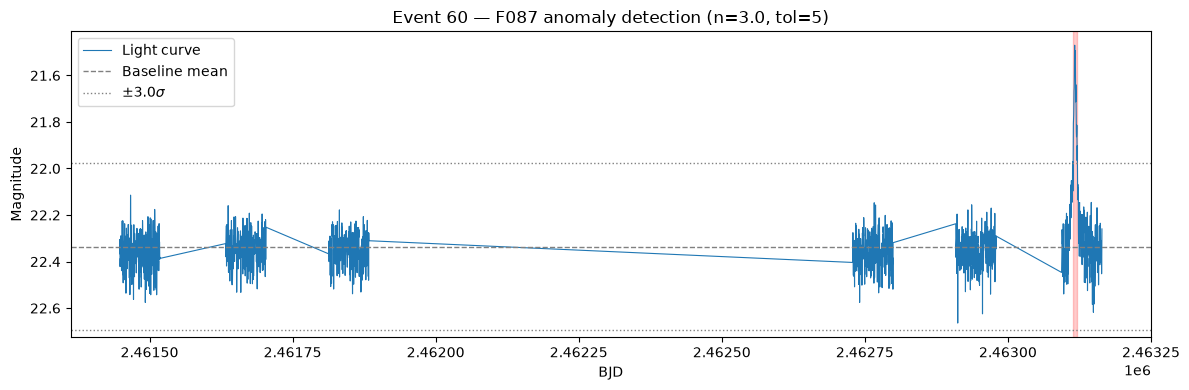

In [49]:
threshold_n = 3.0   # n S.D. from baseline
tol_d = 5            # d consecutive points

event_idx = 60
series = F087_mags[event_idx]
mean = baseline_mean[event_idx]
std = baseline_std[event_idx]

anomalies = find_anomalies(series, mean, std, threshold=threshold_n, tol=tol_d)
print(f"Event {event_idx}: found {len(anomalies)} anomaly window(s): {anomalies}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bjd, series, linewidth=0.8, label="Light curve")
ax.axhline(mean, color="gray", linestyle="--", linewidth=1, label="Baseline mean")
ax.axhline(mean + threshold_n * std, color="gray", linestyle=":", linewidth=1)
ax.axhline(mean - threshold_n * std, color="gray", linestyle=":", linewidth=1, label=f"±{threshold_n}$\\sigma$")

for start, end in anomalies:
    ax.axvspan(bjd[start], bjd[end], color="red", alpha=0.2)

ax.invert_yaxis()
ax.set_xlabel("BJD")
ax.set_ylabel("Magnitude")
ax.set_title(f"Event {event_idx} — F087 anomaly detection (n={threshold_n}, tol={tol_d})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Each event's light curve is observed in 6 separate campaigns, with
# large time gaps between them. bjd is a shared grid across all events, so
# the boundaries are the same for every event.

def find_chunks(time_axis, gap_threshold=10.0):
    """Split a shared time axis into contiguous observing chunks, breaking
    wherever the gap between consecutive points exceeds gap_threshold (days)."""
    gaps = np.diff(time_axis)
    break_points = np.where(gaps > gap_threshold)[0]
    starts = np.concatenate(([0], break_points + 1))
    ends = np.concatenate((break_points, [len(time_axis) - 1]))
    return list(zip(starts.tolist(), ends.tolist()))

def chunk_containing(idx, chunks):
    for c_idx, (start, end) in enumerate(chunks):
        if start <= idx <= end:
            return c_idx
    raise ValueError(f"index {idx} not inside any chunk")

chunks = find_chunks(bjd)
print(f"Found {len(chunks)} chunks: {chunks}")

# Run anomaly detection across every event, and save the detected windows

records = []
for i in range(F087_mags.shape[0]):
    for (start, end) in find_anomalies(F087_mags[i], baseline_mean[i], baseline_std[i], threshold=threshold_n, tol=tol_d):
        c_idx = chunk_containing(start, chunks)
        chunk_start, chunk_end = chunks[c_idx]
        records.append({
            "event_idx": i,
            "start_idx": start,
            "end_idx": end,
            "start_bjd": bjd[start],
            "end_bjd": bjd[end],
            "n_points": end - start + 1,
            "chunk_idx": c_idx,
            "chunk_start_idx": chunk_start,
            "chunk_end_idx": chunk_end,
            "chunk_start_bjd": bjd[chunk_start],
            "chunk_end_bjd": bjd[chunk_end],
        })

anomalies_df = pd.DataFrame(records)
print(f"Found {len(anomalies_df)} anomalies across {anomalies_df['event_idx'].nunique()} events")
anomalies_df.to_csv("data/F087_anomalies.csv", index=False)
anomalies_df.head()

Found 91 anomalies across 91 events


,event_idx,start_idx,end_idx,start_bjd,end_bjd,n_points,chunk_idx,chunk_start_idx,chunk_end_idx,chunk_start_bjd,chunk_end_bjd
0,0,368,394,2.461670e+06,2.461678e+06,27,1,240,480,2.461633e+06,2.461703e+06
1,1,792,811,2.462749e+06,2.462755e+06,20,3,723,962,2.462729e+06,2.462799e+06
2,2,850,904,2.462766e+06,2.462782e+06,55,3,723,962,2.462729e+06,2.462799e+06
3,5,1264,1312,2.463112e+06,2.463125e+06,49,5,1205,1444,2.463094e+06,2.463164e+06
4,6,481,546,2.461813e+06,2.461832e+06,66,2,481,722,2.461813e+06,2.461883e+06


In [ ]:
# We K-shape the whole observing campaign that each anomaly falls in.
# Each is basically the same length.
# edge-pad the shorter ones up to the longest length
# No data lost

CHUNK_LEN = max(end - start + 1 for start, end in chunks)

def pad_segment(series, start, end, length=CHUNK_LEN):
    seg = series[start:end + 1]
    pad_width = length - len(seg)
    if pad_width > 0:
        seg = np.pad(seg, (0, pad_width), mode="edge")
    return seg

anomaly_shapes = np.array([
    pad_segment(F087_mags[row.event_idx], row.chunk_start_idx, row.chunk_end_idx)
    for row in anomalies_df.itertuples()
]).reshape(-1, CHUNK_LEN, 1)

anomaly_shapes_norm = TimeSeriesScalerMeanVariance().fit_transform(anomaly_shapes)

n_clusters = 3

ks_anomaly = KShape(n_clusters=n_clusters, random_state=0)
anomaly_labels = ks_anomaly.fit_predict(anomaly_shapes_norm)

anomalies_df["cluster"] = anomaly_labels
print(np.bincount(anomaly_labels, minlength=n_clusters))

[30 36 25]


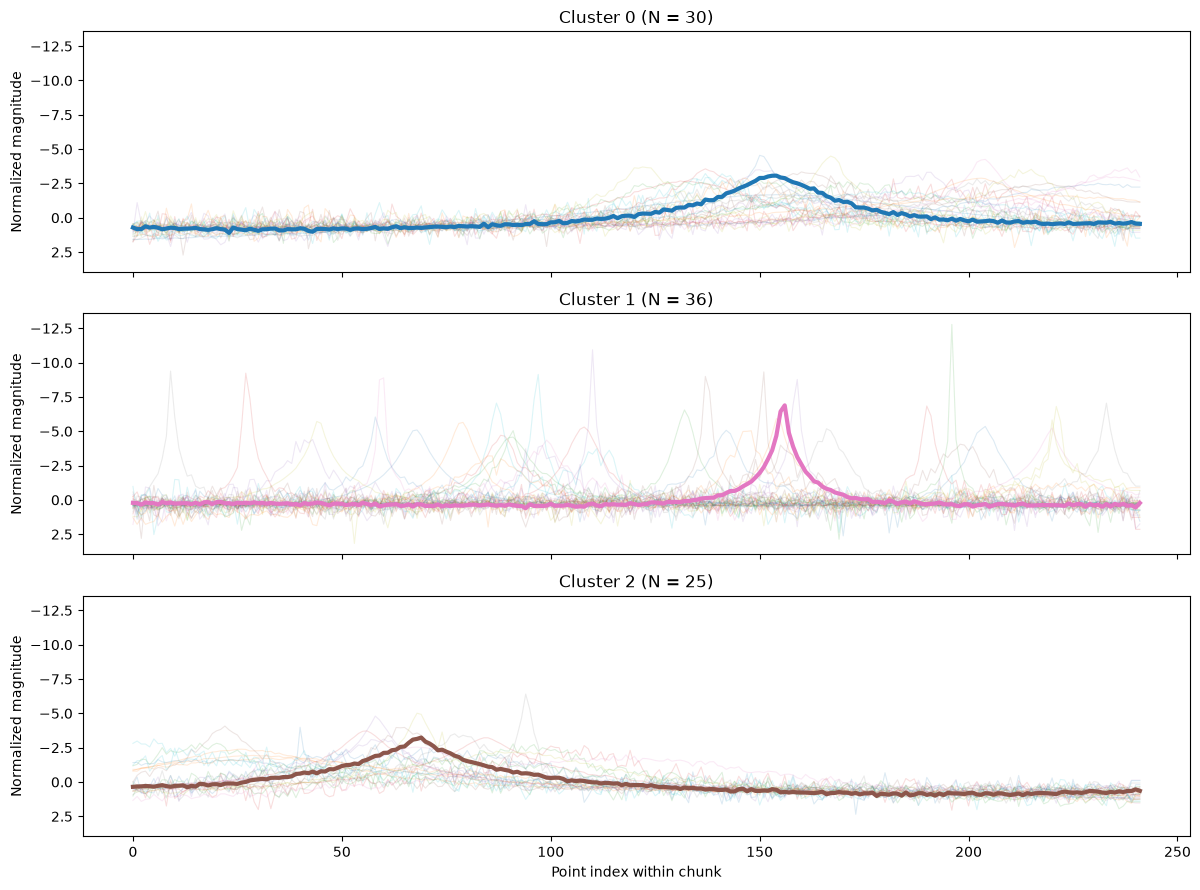

In [58]:
# Point index within the chunk, shared across all padded shapes
anomaly_time = np.arange(CHUNK_LEN)

fig, axes = plt.subplots(n_clusters,1,figsize=(12, 3*n_clusters),sharex=True,sharey=True)

for cluster in range(n_clusters):

    ax = axes[cluster]

    cluster_data = anomaly_shapes_norm[anomaly_labels == cluster, :, 0]

    # Individual chunk shapes
    if len(cluster_data) > 0:
        ax.plot(anomaly_time,cluster_data.T,alpha=0.15,linewidth=0.8)

    # K-Shape centroid
    centroid = ks_anomaly.cluster_centers_[cluster, :, 0]

    ax.plot(anomaly_time,centroid,linewidth=3)

    ax.set_ylabel("Normalized magnitude")
    ax.set_title(f"Cluster {cluster} (N = {len(cluster_data)})")

axes[0].invert_yaxis()
axes[-1].set_xlabel("Point index within chunk")

plt.tight_layout()
plt.show()